# logistic regression
logistic regression is a supervised learning algorithm used to predict the probability of a categorical dependent variable. It is a linear model that uses a sigmoid function to map the linear combination of input features to a probability between 0 and 1. The model is trained using gradient descent to minimize the loss function, which is the negative log likelihood of the true labels given the predicted probabilities. The model is often used for binary classification problems, but it can also be used for multi-class classification problems.




## Assumptions of Logistic Regression

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler




In [4]:
# load the titanic data
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
# pre process the data
# remove the deck column 
# df.drop("deck",axis=1,inplace=True)
# impute missing values in age and fare 
df["age"].fillna(df["age"].median(),inplace=True)
df["fare"].fillna(df["fare"].median(),inplace=True)
# impute missing values in embarked and embarked_town
df["embarked"].fillna(df["embarked"].mode()[0],inplace=True)
df["embark_town"].fillna(df["embark_town"].mode()[0],inplace=True)
# encode the categorical variables using for loop where object and category datatypes are given
for col in df.columns:
    if df[col].dtype == "object" or df[col].dtype == "category":
        df[col] = LabelEncoder().fit_transform(df[col])
df.head()

C:\Users\nasik\AppData\Local\Temp\ipykernel_21932\314347854.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(),inplace=True)
C:\Users\nasik\AppData\Local\Temp\ipykernel_21932\314347854.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [13]:
# X and y column 
X = df.drop("survived",axis=1)
y = df["survived"]  

In [14]:
# train test split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
# model call 
model = LogisticRegression()

In [16]:
# train the model 
model.fit(X_train,y_train)

c:\Users\nasik\miniconda3\envs\python_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
# predict the values
y_pred = model.predict(X_test)

In [18]:
# evaluate the model 
print("accuracy score:",accuracy_score(y_test,y_pred))
print("recall score:",recall_score(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))

accuracy score: 1.0
recall score: 1.0
precision score: 1.0
f1 score: 1.0
confusion matrix:
 [[119   0]
 [  0  60]]
classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       119
           1       1.00      1.00      1.00        60

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



Text(95.72222222222221, 0.5, 'Actual')

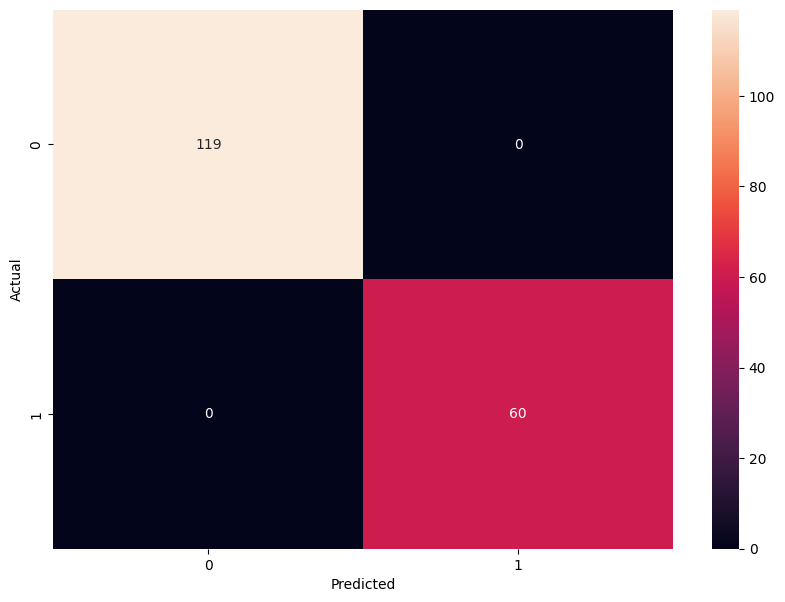

In [21]:
# plot the confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [22]:
# save the model 
import pickle
pickle.dump(model,open("./save models/02_model_logistic_regression.pkl","wb"))